# Example 1 - Modelling a Duotransit

Let's walk through how to model a duotransit with `MonoTools`.

First, some imports:

In [2]:
from MonoTools.MonoTools import fit,tools,starpars,lightcurve

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## E1 - Loading the lightcurve

Let's download the target lightcurve using the attached `lightcurve` module.

`use_fast=False` means we do not download the 20s cadence data, which slows down the modelling!

We can then plot the lightcurve using `lc.plot()` (here we don't need to save the plot)

Getting all IDs
Accessing online catalogues to match ID to RA/Dec (may be slow) mission= tess
92 91
Sector 92 not (yet) found on MAST | RESPONCE:404
None


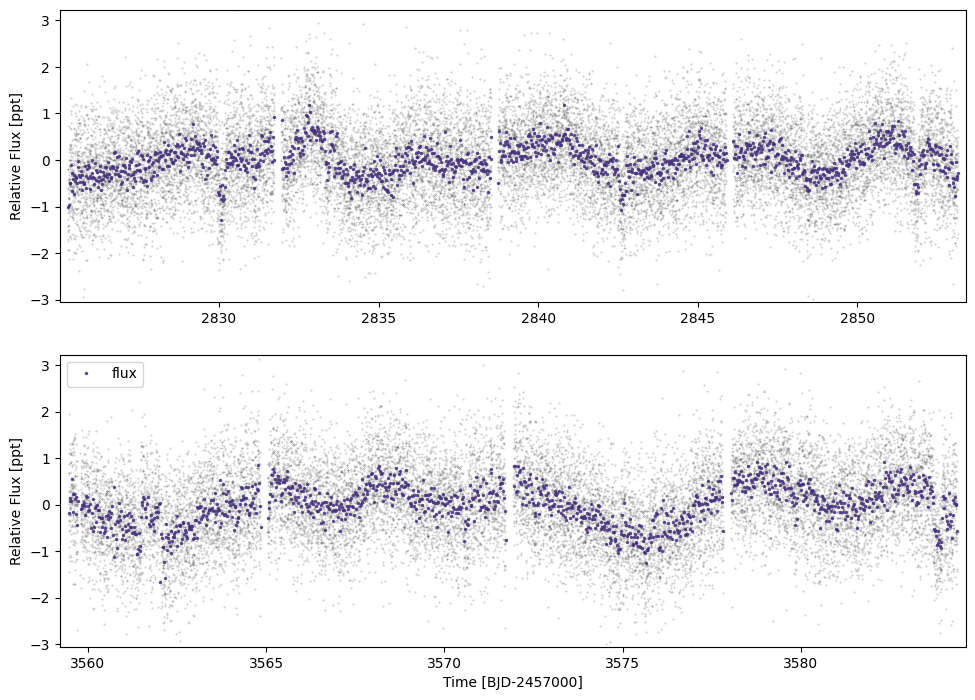

In [6]:
tic=431810418
lc=lightcurve.multilc(tic,'tess',save=False,load=False,use_fast=False)
lc.plot(savepng=False,savepdf=False)

In [ ]:
ticalc=lightcurve.lc()
sect=83
t=np.hstack([pd.read_csv(f,index_col=0)['time'].values for f in glob.glob("/Users/hugh/Postdoc/Cheops/TICA_lightcurves/TIC"+str(tic)+"_TICA_S*_lc.csv")])
f=np.hstack([1000*(pd.read_csv(f,index_col=0)['flux_ap_1.5'].values/np.nanmedian(pd.read_csv(f,index_col=0)['flux_ap_1.5'])-1) for f in glob.glob("/Users/hugh/Postdoc/Cheops/TICA_lightcurves/TIC"+str(tic)+"_TICA_S*_lc.csv")])
rawf=np.hstack([1000*(pd.read_csv(f,index_col=0)['raw_flux'].values/np.nanmedian(pd.read_csv(f,index_col=0)['raw_flux'])-1) for f in glob.glob("/Users/hugh/Postdoc/Cheops/TICA_lightcurves/TIC"+str(tic)+"_TICA_S*_lc.csv")])
bgf=np.hstack([pd.read_csv(f,index_col=0)['bg_flux'].values for f in glob.glob("/Users/hugh/Postdoc/Cheops/TICA_lightcurves/TIC"+str(tic)+"_TICA_S*_lc.csv")])
ferr=np.hstack([1000*(np.sqrt(pd.read_csv(f,index_col=0)['flux_err'].values)/pd.read_csv(f,index_col=0)['flux_ap_1.5'].values) for f in glob.glob("/Users/hugh/Postdoc/Cheops/TICA_lightcurves/TIC"+str(tic)+"_TICA_S*_lc.csv")])
ticalc.load_lc(time=np.sort(t),
              fluxes={'flux':f[np.argsort(t)],
                      'raw_flux':rawf[np.argsort(t)],
                      'bg_flux':bgf[np.argsort(t)]},
              flux_errs={'flux_err':ferr},
              flx_system='ppt',src='tica',mission='tess',jd_base=2457000,sect=sect)
lc=lightcurve.multilc(tic,'tess',save=False,load=False,extralc=ticalc,priorities=['ts_20_pdc','ts_120_pdc','ts_200_tica'])
lc.plot(savepng=False,savepdf=False)

#### E1 - Plotting the transit positions
By passing a dictionary of dicts to `plot_ephem`. We also constrain y-axis using `ylim`:

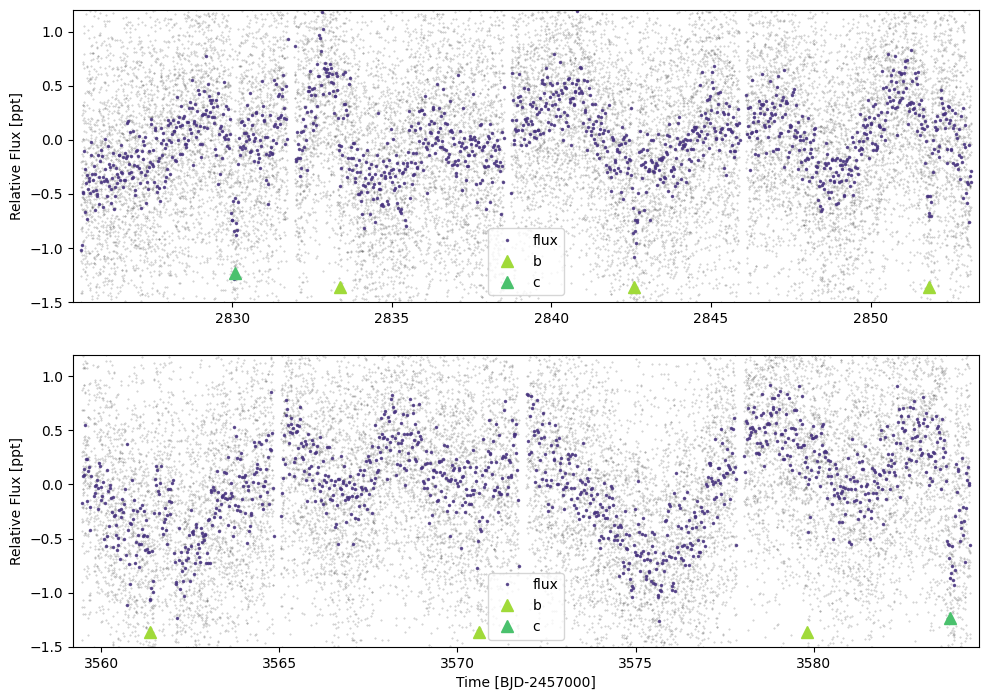

In [8]:
ephs={'b':{'p':(3570.6-2842.6)/np.round((3570.6-2842.6)/(2851.85-2842.6)),'t0':2842.6,'dur':0.18},
      'c':{'p':(3583.82-2830.1),'t0':3583.82,'dur':0.24}}#Here we just use the transit span as p
lc.plot(plot_ephem=ephs, timeseries=['flux'], ylim=(-1.5,1.2), savepng=False, savepdf=False)

## E1 -  Initialising the model with a duotransit and multiplanet

The initial `fit.monoModel` class needs the TIC ID, the mission name, and the lightcurve itself.

Then we can add planets using `add_multi` and `add_duo`. These require dictionaries with the ephemeris and depth, as well as (crucially) the planet name.

`init_starpars` then either takes user-defined stellar parameters (e.g. `Rstar=[Rs_med,Rs_neg_err,Rs_pos_err]`, and same for rhostar, Mstar, logg). In the default case, stellar parameters come from the TIC (v8) catalogue.

We can then initialise the lightcurve and the model

In [10]:
mod=fit.monoModel(tic,'tess',lc=lc)
#mod.add_multi({'tcen':ephs['b']['t0'],'period':ephs['b']['p'],'tdur':ephs['b']['dur'],'depth':0.4e-3},'b')#,update_per=False)
mod.add_multi({'tcen':ephs['b']['t0'],'period':ephs['b']['p'],'tdur':ephs['b']['dur'],'depth':0.55e-3},'b')
mod.add_duo({'tcen':ephs['c']['t0'],'tcen_2':ephs['c']['t0']-ephs['c']['p'],'tdur':ephs['c']['dur'],'depth':0.7e-3},'c')
mod.init_starpars()

{'tcen': 3583.82, 'tcen_2': 2830.1, 'tdur': 0.24, 'depth': 0.0007, 'tcens': array([3583.82, 2830.1 ]), 'span': 753.7200000000003, 'period_int_aliases': array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30.])}


## E1 -  Initialising the lightcurve without a GP

There are two main options - with or without a Gaussian Process. 

Without a Gaussian Process (`use_GP=False`) will use a bspline-fitting method (masking the identified transits). This will be faster, but in cases with relatively high-amplitude noise/stellar activity close in duration to the transit, a GP will be more robust. In this case, we do not need all of the data, so we can cut the out-of-transit data, here to 2.5 transit durations from t0, using `cut_distance=2.5`.

In the case of `use_GP=True`, `bin_oot=True` allows for photometry far-from-transit to be binned in order to speed up computation time. Alternatively, `bin_all=True` will bin all the data including in-transit points. Alternatively `fit_no_flatten=True` will not perform any flattening and assume the lightcurve is already flat with out-of-transit flux at ~0.0.

In [11]:
mod.init_lc(use_GP=False, cut_distance=2.5, bin_oot=False)

[2825.25645275 3559.42661067] [2853.1429363  3584.37965094]


## E1 -  Initialising the duotransit model

There are many options for model fitting:
- `constrain_LD=True` will constrain the limb darkening coefficients to the theoretical values
- `ld_mult=1.5`. This is the multiplication factor for the theoretical LD params (to account for systematic errors)
- `model_jitter=True` will model a log jitter term for each lightcurve (split into cadences)
- `model_phot_mean=True` will model a mean photometric term for each lightcurve (split into cadences)
- `timing_sigma=0.1` allows the adjustment of the priors on the t0s. The default is to assume they are known to ±0.1tdur.
- `floattype=np.float64` can be adjusted to e.g. `np.float32` to attempt to speed up the model.
- `step_initialise=True` will optimize the model in steps, starting with the most sensitive transit parameters. This is preferred.
- `use_L2=False`. If set to `True`, the model will fit for unincluded "second light" (i.e. contamination)

In [12]:
mod.init_model(constrain_LD=True,ld_mult=1.5,model_jitter=True,model_phot_mean=False,step_initialise=True)

[2825.25645275 3559.42661067] [2853.1429363  3584.37965094]
Initialising ~FAST~ MonoTools model.
initialised planet info
Shape.0
Initialised everything. Optimizing


## E1 -  Plotting the intial duotransit fit

Options here:
- `plot_flat=True` subtracts the spline fit
- `ylim=(-1.5,1.0)` sets ylim on full timeseries plot
- `xlim=(-0.3,0.3)` sets xlim on folded plots
- `savepng=False` does not save a png (default True)
- `savepdf=True` saves a pdf (default False)

initialising transit
Initalising Transit models for plotting with n_samp= 10
phase (5147,) masked_flux 5147 cad_mask 37141 36936 phasebool (37141,) 5183 transmod (5147,) othpls [0. 0. 0. ... 0. 0. 0.] (5147,)
(5147,) (5147,) (5147,) (5147,) (5147,)
phase (1680,) masked_flux 1680 cad_mask 37141 36936 phasebool (37141,) 1680 transmod (1680,) othpls [0. 0. 0. ... 0. 0. 0.] (1680,)
(1680,) (1680,) (1680,) (1680,) (1680,)
0.12964546154463585
0.20641507580074672


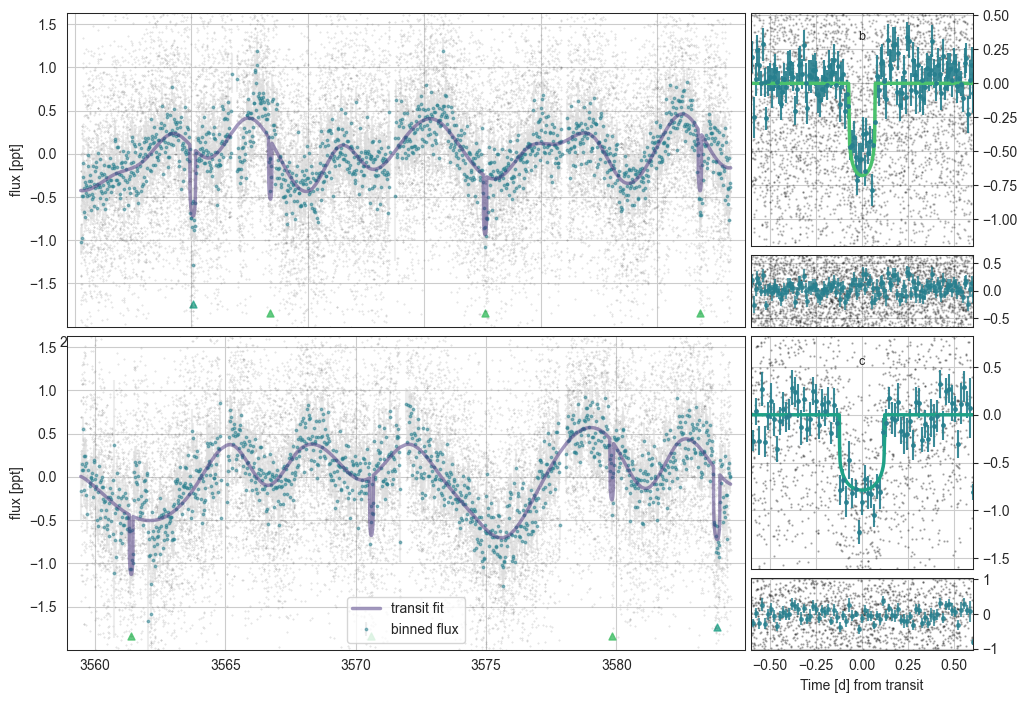

In [14]:
mod.plot(savepng=False)

## E1 - Sampling the duotransit model

The sampling can be modified in the following ways:
- `n_draws=1800` is the number of (post-burn-in) samples per chain
- `n_chains=6` is the number of chains
- `cores=6` is the number of CPU cores to run on.
- `sample_method=pm.NUTS` allows for the ability to run pymc samplers

In [15]:
mod.sample_model(n_draws=1000,n_chains=6,cores=6)

Multiprocess sampling (6 chains in 6 jobs)
NUTS: [Rs, rhostar, t0_b, per_b, logror_b, b_b, t0_c, logror_c, b_c, tdur_c, q_star_tess, log_jitter_ts_120]


Sampling 6 chains for 660 tune and 1_000 draw iterations (3_960 + 6_000 draws total) took 690 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 4 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 5 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher 

Saving sampled model parameters to file with shape:  (21, 14)


## E1 - Plotting the outputs

The models are interpolated to the full input lightcurve and stored in `mod.trans_to_plot` and `mod.gp_to_plot`.

`overwrite=True` re-extracts these transit and spline models from the trace. `plot_2sig=True` plots both 1 and 2 sigma regions.

initialising transit
Initalising Transit models for plotting with n_samp= 990
phase (5148,) masked_flux 5148 cad_mask 37141 36936 phasebool (37141,) 5184 transmod (5148,) othpls [0. 0. 0. ... 0. 0. 0.] (5148,)
(5148,) (5148,) (5148,) (5148,) (5148,)
phase (1686,) masked_flux 1686 cad_mask 37141 36936 phasebool (37141,) 1686 transmod (1686,) othpls [0. 0. 0. ... 0. 0. 0.] (1686,)
(1686,) (1686,) (1686,) (1686,) (1686,)
0.13251834087207237
0.17088097275379405


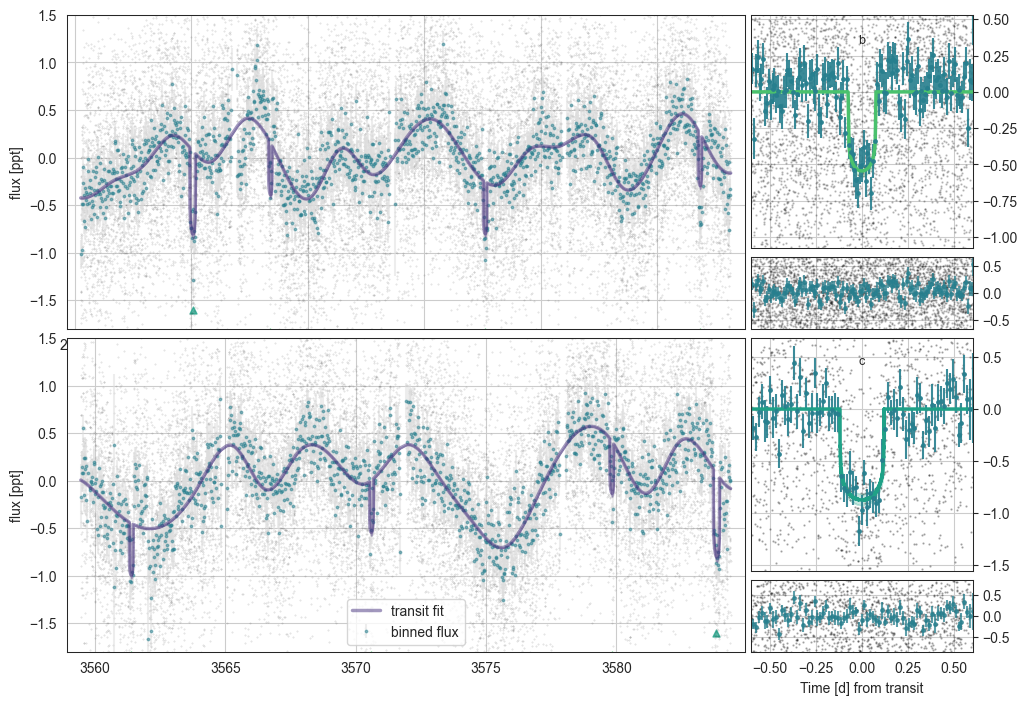

In [17]:
mod.plot(overwrite=True, plot_2sig=False,ylim=(-1.8,1.5))

variables for Corner: ['Rs', 'rhostar', 'logror_b', 'b_b', 'tdur_b', 't0_b', 'logror_c', 'b_c', 'tdur_c', 't0_c']
['Rs', 'rhostar', 'logror_b', 'b_b', 'tdur_b', 't0_b', 'logror_c', 'b_c', 'tdur_c', 't0_c']


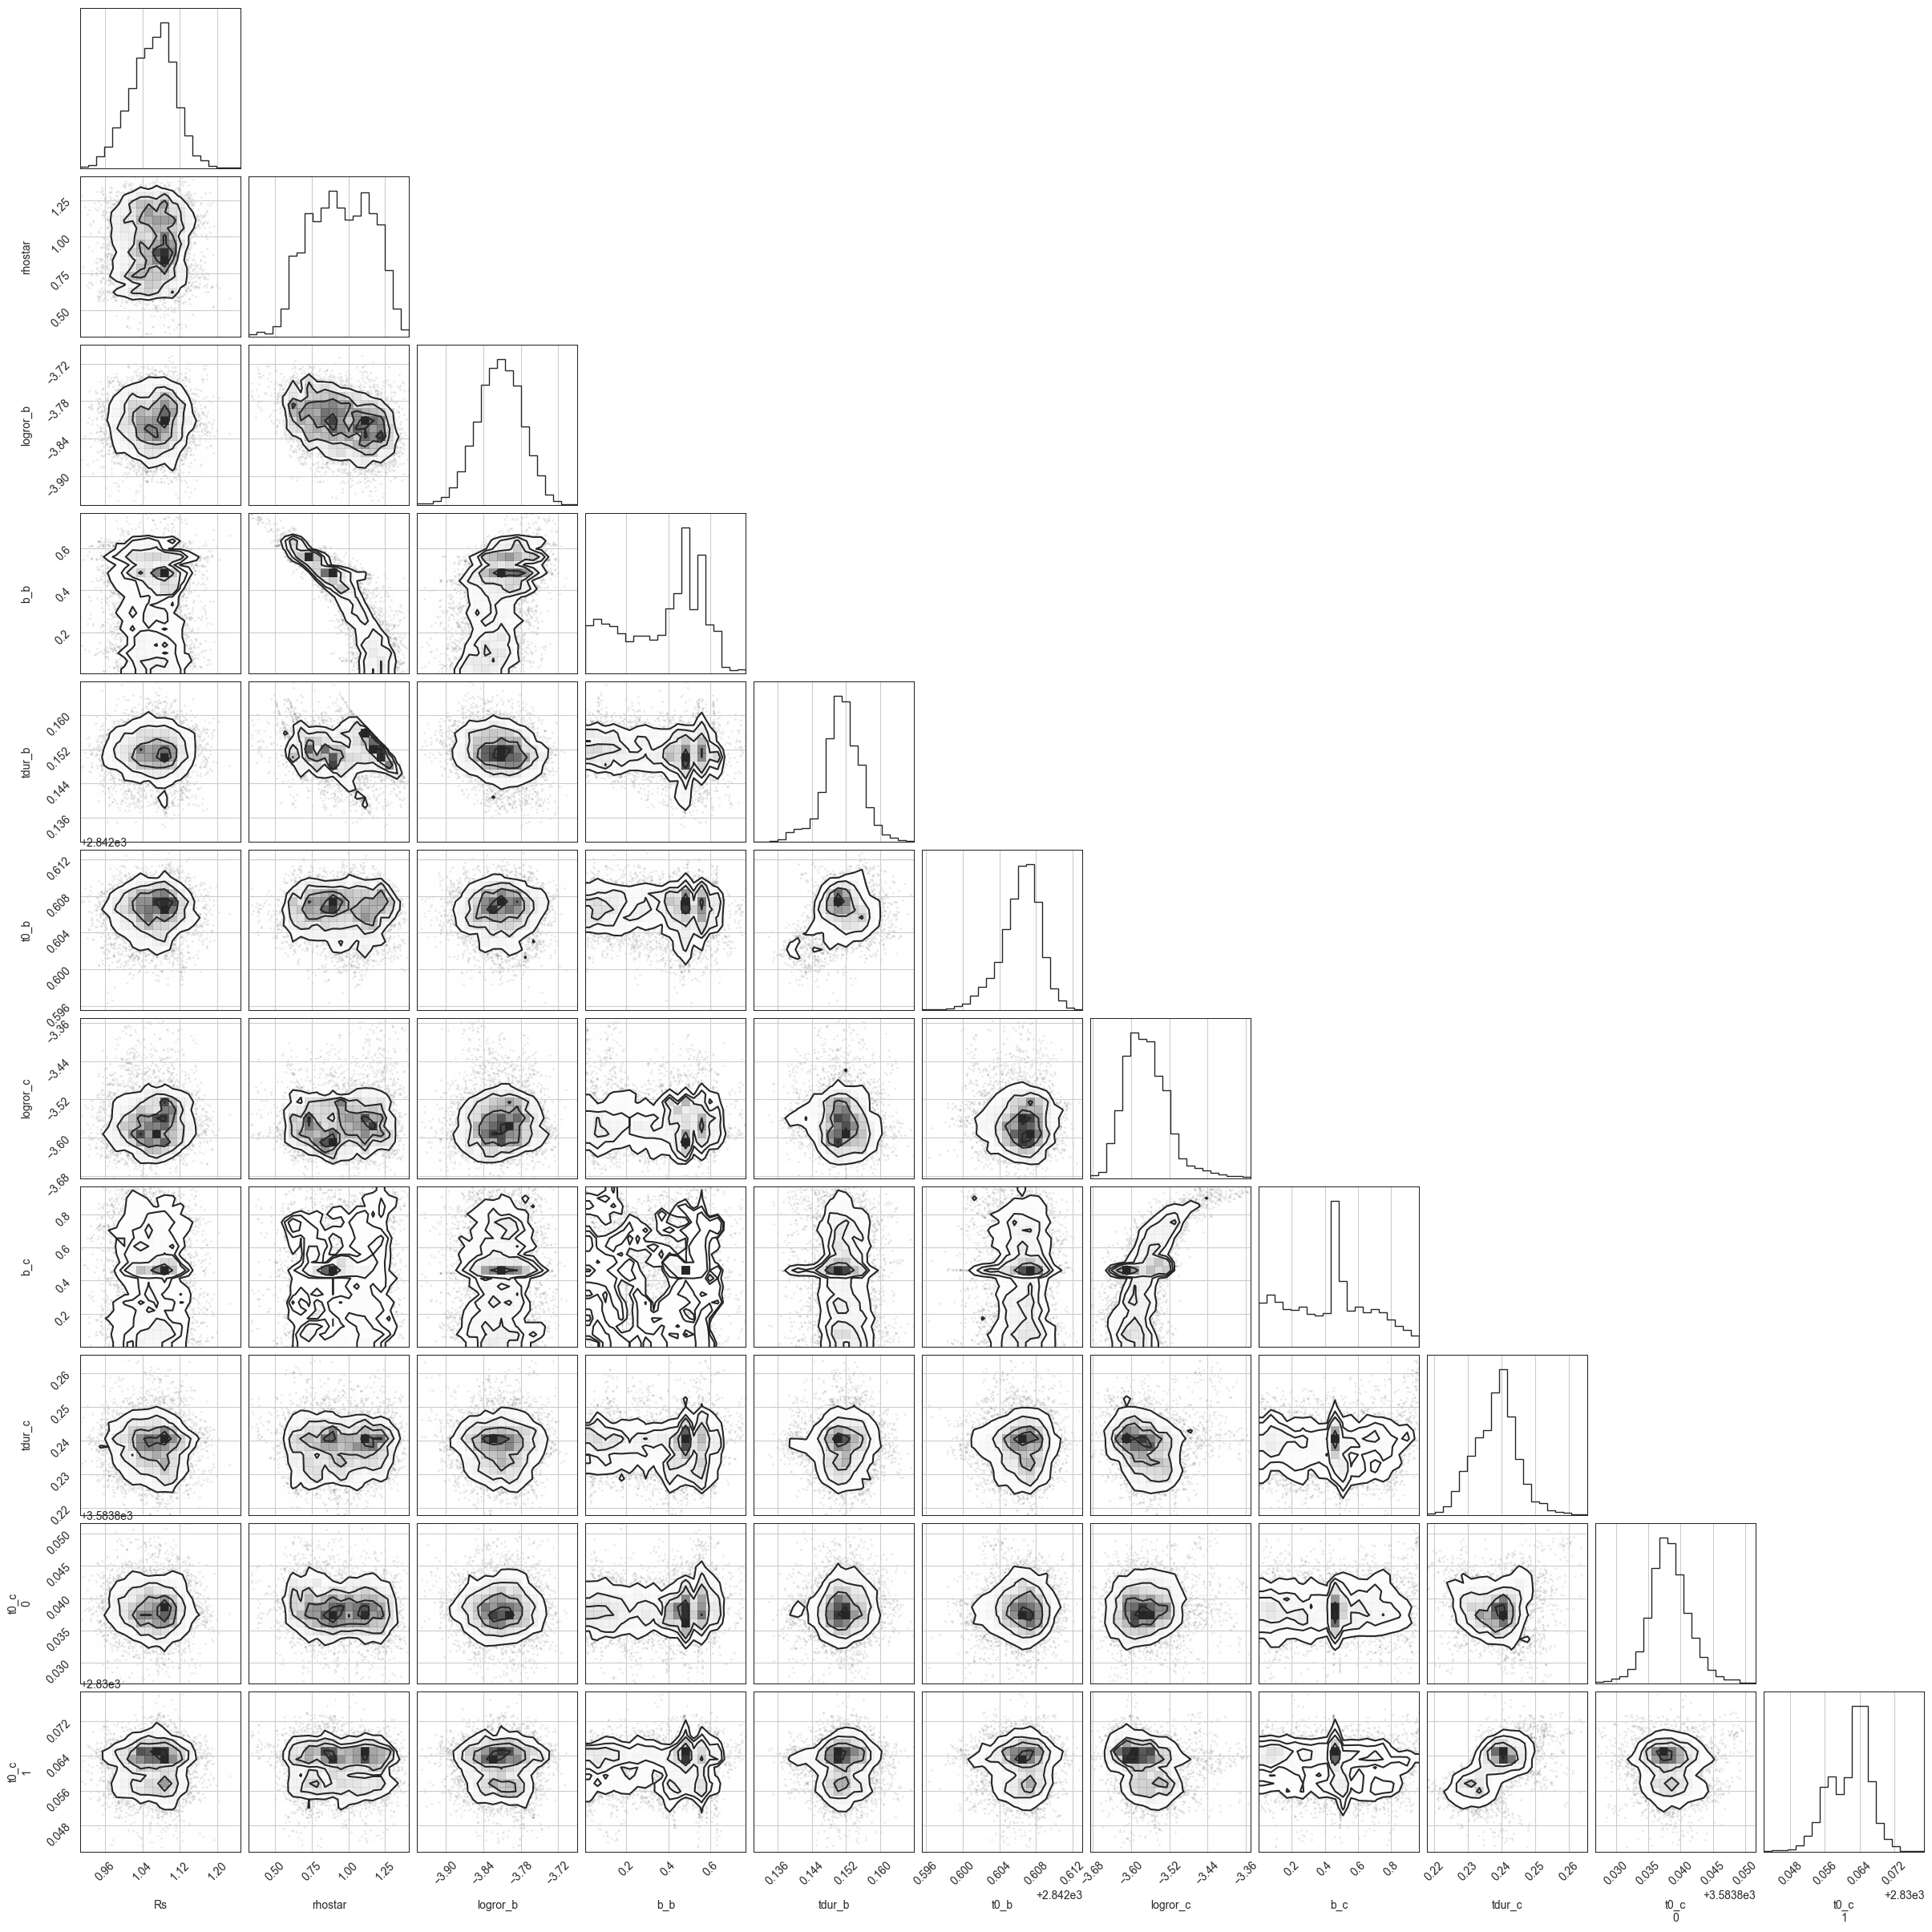

In [18]:
mod.plot_corner()

We need to run these models for longer (and potentially prune the b=0.5 outlier here).

## E1 -  Computing the period probabilities _a posteriori_

In this new version, we fit the transits in a way ambivalent to the periods, and instead only assess the period probabilities using the trace (and various priors). To do this, you have to call `mod.assess_period_from_posterior()`

### E1 - IMPORTANT ASIDE - Eccentricity priors
At this point, key choices have to be made about the eccentricity prior by updating `ecc_prior='auto'`. This is extremely important, as *the uncertainty in your derived period distribution depends highly on the eccentricity prior*, so choose an option that you believe best matches your planet/planetary system. There are the following options:
- `ecc_prior='uniform'` - Planets don't have this distribution in reality. Don't use this. 
- `ecc_prior='kipping'` - The (close-in) Kipping 2013 prior. Derived from RV planets, and therefore dominated by high-mass planets. Potentially OK in those cases.
- `ecc_prior='vaneylen'` - Specifically the multi-planet version derived in VanEylen 2018. Measured for compact multi systems in Kepler. The most e=0-biased prior available (therefore, potentially, the best period logprob constraints)
- `ecc_prior='bernmodel_sing'` - Derived from single planets as produced by Bern model full-system simulations. No observational biases. The Bern Model priors are also all radius-dependent using the initial radius to choose one distribution from [terrestrials, Neptunians or Giants]. The giant case matches `kipping` well, while the smaller planets are much more low-eccentricity.
- `ecc_prior='bernmodel_mult'` - Derived from multi systems produced by Bern model. Radius-dependent (rocky, Neptunian & Giants). These, especially for small planets, are well-constrained to e~0 (though less so than `vaneylen`).
- `ecc_prior='bernmodel_both'` - Derived from all (observable) planets as produced by Bern model full-system simulations.
- `ecc_prior='auto'` - The default is the (radius-constrained) `bernmodel_both` prior for single cases (as we do not know if there could be additional planets), and the `bernmodel_mult` in multi cases.

In [29]:
mod.assess_period_from_posterior()

multis__bernmodel auto {'kipping': 'kip', 'vaneylen': 'vve', 'flat': 'flat', 'apogee': 'apo', 'bernmodel_both': 'both__bernmodel', 'bernmodel_sing': 'singles__bernmodel', 'bernmodel_mult': 'multis__bernmodel', 'auto': 'multis__bernmodel'} mult ['bern', 'auto']


#### E1 -  Viewing the derived parameters

`mod.make_table()` creates (and saves) the posterior statistics. Check that `ess` is at least a thousand, and `r_hat` is well below 1.05 (ideally below 1.01).

In [30]:
tab=mod.make_table()
tab.to_csv("TOI5968_TIC431810418_best_fit_data.csv")
tab.iloc[:25]

Saving sampled model parameters to file with shape:  (328, 14)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,5%,-$1\sigma$,median,+$1\sigma$,95%
Rs,1.06189,0.04634,0.97166,1.14453,0.00324,0.00229,221.82731,1076.29584,1.03780,0.98059,1.01383,1.06552,1.10589,1.13321
rhostar,0.94808,0.20533,0.60120,1.29347,0.05671,0.04103,14.06207,84.21169,1.35297,0.62333,0.72072,0.94833,1.17599,1.26266
t0_b,2842.60631,0.00213,2842.60199,2842.61013,0.00014,0.00010,285.45446,239.01105,1.01701,2842.60231,2842.60430,2842.60656,2842.60824,2842.60936
per_b,9.21519,0.00000,9.21518,9.21519,0.00000,0.00000,514.51917,907.03338,1.01120,9.21519,9.21519,9.21519,9.21519,9.21519
logror_b,-3.81360,0.03562,-3.88098,-3.74818,0.00490,0.00349,53.82261,532.60427,1.08189,-3.87322,-3.84942,-3.81321,-3.77804,-3.75564
t0_c[0],3583.83830,0.00309,3583.83255,3583.84433,0.00016,0.00012,412.95200,405.44537,1.01348,3583.83351,3583.83553,3583.83813,3583.84120,3583.84356
t0_c[1],2830.06183,0.00471,2830.05276,2830.06977,0.00046,0.00033,114.73809,462.41245,1.04549,2830.05368,2830.05659,2830.06294,2830.06604,2830.06843
logror_c,-3.56762,0.04664,-3.65003,-3.48594,0.00828,0.00593,29.92106,137.17971,1.14933,-3.63306,-3.61136,-3.57202,-3.52643,-3.48636
tdur_c,0.23838,0.00647,0.22511,0.24940,0.00057,0.00040,137.31682,355.47911,1.04165,0.22770,0.23171,0.23882,0.24407,0.24860
log_jitter_ts_120,-1.69956,0.20648,-2.08548,-1.37996,0.01504,0.01126,287.80270,222.07193,1.02313,-2.07737,-1.86880,-1.66404,-1.51849,-1.44411


## E1 -  Plotting the orbital period posterior probability distribution

This is, in many ways, the key figure. What is the most likely orbital period?

Options: `ymin=-4`, `pmin=23`, `pmax=300`, etc.

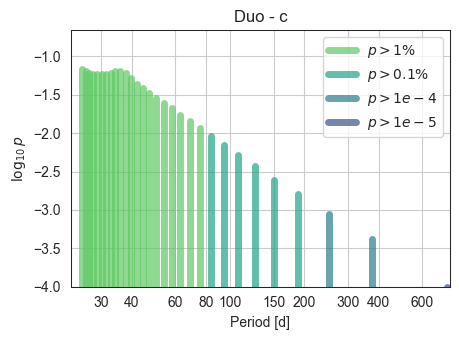

In [32]:
mod.plot_periods(ymin=-4)

The general decreasing trend is due to the various priors (geometric, etc) which prefer short periods. The "bump" here is likely due to the circular/low eccentricity regime peaking around this value. A more constraining eccentricity prior may change the result...

## E1 - Saving the duotranist model

In [33]:
mod.save_model_to_file()

## E1 - Predicting upcoming transits for all aliases

Using `mod.predict_future_transits()`
- We can specify a time range using `time_start` and `time_end` via `astropy.time.Time` objects (`time_end=Time("2026-01-01T00:00:00.0",format='isot')`), or use `time_dur=500` to ask for a prediction 500 days into the future.
- We can check which transits are TESS observed using `check_TESS=True` (default)
- We can use `compute_solsys_dist=True` to compute sun and moon distances (CHEOPS observations are possible when `sun_dist>117` and `moon_dist>15`).

In [35]:
trans=mod.predict_future_transits(time_dur=500)
trans.to_csv("TOI5968_TIC431810418_trans_table.csv")

time range 2025-06-05T15:50:38.491 -> 2026-10-18T15:50:38.492


In [36]:
trans

,transit_mid_date,transit_mid_med,transit_dur_med,transit_dur_-1sig,transit_dur_+1sig,transit_start_+2sig,transit_start_+1sig,transit_start_med,transit_start_-1sig,transit_start_-2sig,...,planet_name,alias_n,alias_p,aliases_ns,aliases_ps,total_prob,num_aliases,in_TESS,sun_separation,moon_separation
0,2025-06-11T08:19:46.470,3837.847066,0.151122,0.147437,0.155233,3837.780293,3837.775057,3837.771504,3837.767152,3837.761926,...,multi_b,0,9.21519,0,9.2152,1.0,1.0,False,78.389208,104.101889
1,2025-06-20T13:29:38.506,3847.062251,0.151122,0.147437,0.155233,3846.995484,3846.990248,3846.986690,3846.982342,3846.977116,...,multi_b,0,9.21519,0,9.2152,1.0,1.0,False,85.759439,34.597295
2,2025-06-29T18:39:30.858,3856.277440,0.151122,0.147437,0.155233,3856.210674,3856.205440,3856.201879,3856.197533,3856.192305,...,multi_b,0,9.21519,0,9.2152,1.0,1.0,False,93.154198,135.076334
3,2025-07-08T23:49:23.402,3865.492632,0.151122,0.147437,0.155233,3865.425865,3865.420632,3865.417071,3865.412723,3865.407495,...,multi_b,0,9.21519,0,9.2152,1.0,1.0,False,100.520485,100.490479
4,2025-07-18T04:59:15.844,3874.707822,0.151122,0.147437,0.155233,3874.641056,3874.635824,3874.632261,3874.627914,3874.622685,...,multi_b,0,9.21519,0,9.2152,1.0,1.0,False,107.811175,36.950328
5,2025-07-27T10:09:08.164,3883.923011,0.151122,0.147437,0.155233,3883.856244,3883.851016,3883.847450,3883.843103,3883.837874,...,multi_b,0,9.21519,0,9.2152,1.0,1.0,False,114.972771,137.466355
6,2025-08-05T15:19:00.702,3893.138203,0.151122,0.147437,0.155233,3893.071435,3893.066207,3893.062641,3893.058292,3893.053062,...,multi_b,0,9.21519,0,9.2152,1.0,1.0,False,121.918730,97.328477
7,2025-08-14T20:28:53.184,3902.353393,0.151122,0.147437,0.155233,3902.286626,3902.281398,3902.277832,3902.273482,3902.268249,...,multi_b,0,9.21519,0,9.2152,1.0,1.0,False,128.531425,40.122646
8,2025-08-24T01:38:45.491,3911.568582,0.151122,0.147437,0.155233,3911.501817,3911.496588,3911.493021,3911.488671,3911.483437,...,multi_b,0,9.21519,0,9.2152,1.0,1.0,False,134.641085,139.822349
9,2025-09-02T06:48:37.888,3920.783772,0.151122,0.147437,0.155233,3920.717004,3920.711777,3920.708211,3920.703860,3920.698624,...,multi_b,0,9.21519,0,9.2152,1.0,1.0,False,139.976969,94.383946


In [ ]:
# Pre-initialisation step (for me) to run before the rest of the notebook
# The followg may need to be MonoTools.MonoTools if you are outside the MonoTools folder when importing:
import os
os.environ['MONOTOOLSPATH']='/Users/hugh/Postdoc/Cheops/Duotransits'
import pytensor
pytensor.config.gcc__cxxflags = '-fbracket-depth=512'
%load_ext autoreload
%autoreload 2